In [2]:
import os
print(os.listdir('/kaggle/input/datasets'))

['rashikrahmanpritom']


2026-05-29 07:12:15.465340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780038735.675017      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780038735.747751      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780038736.280403      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780038736.280444      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780038736.280447      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0

--- Loading Datasets ---
Found 1322 files belonging to 3 classes.


I0000 00:00:1780038752.430236      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780038752.436316      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.

Detected Class Labels Successfully: ['Healthy', 'Powdery', 'Rust']


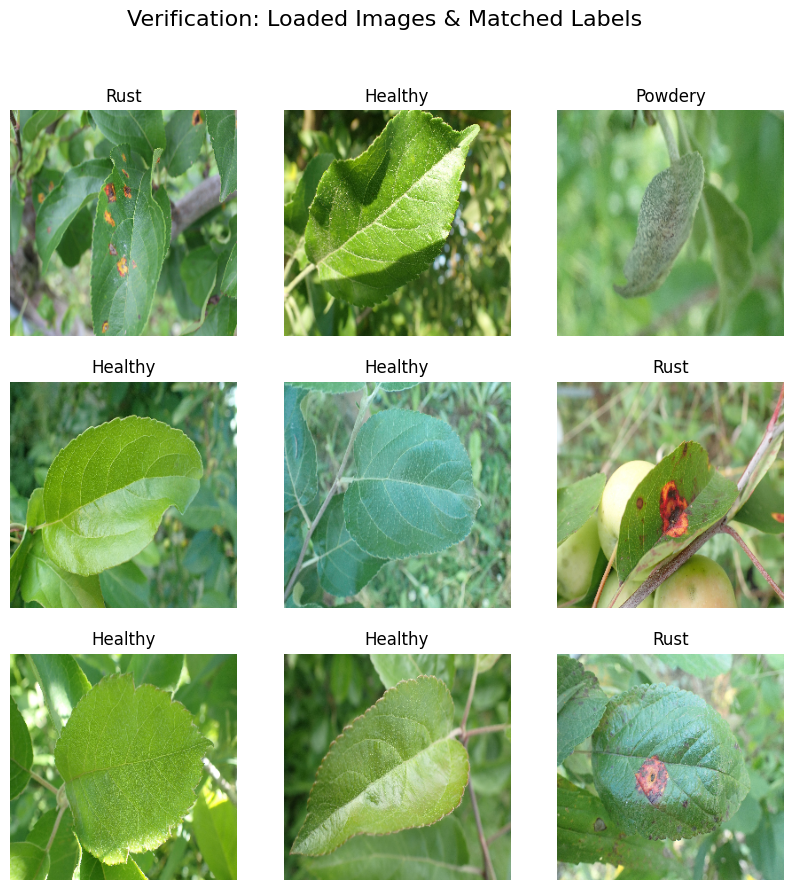

In [3]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Clear out background CUDA warning clutter from your output window
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

print("TensorFlow version:", tf.__version__)

# 2. Define the absolute, correct paths discovered on your Kaggle server drive
ROOT_PATH = "/kaggle/input/datasets/rashikrahmanpritom/plant-disease-recognition-dataset"
TRAIN_DIR = f"{ROOT_PATH}/Train/Train"
VAL_DIR = f"{ROOT_PATH}/Validation/Validation"
TEST_DIR = f"{ROOT_PATH}/Test/Test"

print("\n--- Loading Datasets ---")

# 3. Load the Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(256, 256), batch_size=32, shuffle=True
)

# 4. Load the Validation Dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR, image_size=(256, 256), batch_size=32, shuffle=False
)

# 5. Load the Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(256, 256), batch_size=32, shuffle=False
)

# 6. Extract and print the detected class names to confirm success
class_names = train_ds.class_names
print("\nDetected Class Labels Successfully:", class_names)

# 7. VISUALIZE: Display a 3x3 grid of your leaves to verify everything looks right
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Verification: Loaded Images & Matched Labels", fontsize=16)
plt.show()

In [4]:
import numpy as np


# 1. Create a function that can get counts for any dataset
def check_dataset_counts(dataset, dataset_name):
    print(f"\n--- Class Wise Image Counts ({dataset_name} Data) ---")

    all_labels = []
    # Collect all labels from batches into a list
    for images, labels in dataset:
        all_labels.extend(labels.numpy())

    # Use NumPy to count
    unique_labels, counts = np.unique(all_labels, return_counts=True)

    # Print on screen
    for label_idx, count in zip(unique_labels, counts):
        class_name = class_names[label_idx]
        print(f"-> {class_name}: {count} images")

    print(f"Total {dataset_name} Images: {sum(counts)}")
    print("-" * 40)


# 2. Send our three datasets to this function one by one
check_dataset_counts(train_ds, "Training")
check_dataset_counts(val_ds, "Validation")
check_dataset_counts(test_ds, "Testing")


--- Class Wise Image Counts (Training Data) ---
-> Healthy: 458 images
-> Powdery: 430 images
-> Rust: 434 images
Total Training Images: 1322
----------------------------------------

--- Class Wise Image Counts (Validation Data) ---
-> Healthy: 20 images
-> Powdery: 20 images
-> Rust: 20 images
Total Validation Images: 60
----------------------------------------

--- Class Wise Image Counts (Testing Data) ---
-> Healthy: 50 images
-> Powdery: 50 images
-> Rust: 50 images
Total Testing Images: 150
----------------------------------------


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Image parameters used earlier during data loading
IMAGE_SIZE = 256
CHANNELS = 3

print("--- Data Augmentation & CNN Model Architecture is Getting Ready ---")

# 2. DATA AUGMENTATION LAYER (As per your Pipeline Diagram)
# This layer will dynamically transform images during each epoch of training
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal_and_vertical", input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
        ),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ]
)

# 3. MODEL BUILDING (Convolutional Neural Network)
model = models.Sequential(
    [
        # Apply Augmentation first (To solve the data scarcity problem)
        data_augmentation,
        # DATA CLEANING & PREPROCESSING: Scale pixels from 0-255 down to between 0-1
        layers.Rescaling(1.0 / 255),
        # Convolution Layer 1 & Pooling: To capture edges and curves
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Convolution Layer 2 & Pooling: To understand textures and shapes
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Convolution Layer 3 & Pooling: For complex leaf patterns
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Convolution Layer 4 & Pooling: For deep disease features
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Flatten: Convert 2D image data into a 1D single vector
        layers.Flatten(),
        # Dense Layer: The model's brain that will process the features
        layers.Dense(64, activation="relu"),
        # Output Layer: 3 units because we have 3 classes (Healthy, Powdery, Rust)
        # Softmax will give us the final answer as a percentage (%)
        layers.Dense(3, activation="softmax"),
    ]
)

# 4. Compile the model structure and set the rules
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

# Print the summary to see the complete model structure
model.summary()

--- Data Augmentation & CNN Model Architecture is Getting Ready ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,323 (3.42 MB)

 Trainable params: 896,323 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("\n--- Model Training is Starting ---")

# We are training for 20 rounds (epochs)
EPOCHS = 20

history = model.fit(
    train_ds,
    batch_size=32, 
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS,
)


--- Model Training is Starting ---
Epoch 1/20


I0000 00:00:1780038791.809728     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


42/42 ━━━━━━━━━━━━━━━━━━━━ 31s 557ms/step - accuracy: 0.4191 - loss: 1.0339 - val_accuracy: 0.4333 - val_loss: 0.9094
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 528ms/step - accuracy: 0.6611 - loss: 0.7079 - val_accuracy: 0.6333 - val_loss: 0.8259
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 565ms/step - accuracy: 0.8676 - loss: 0.3505 - val_accuracy: 0.8333 - val_loss: 0.3272
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 513ms/step - accuracy: 0.8971 - loss: 0.3419 - val_accuracy: 0.9167 - val_loss: 0.2960
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 549ms/step - accuracy: 0.9145 - loss: 0.2753 - val_accuracy: 0.9000 - val_loss: 0.2924
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 27s 633ms/step - accuracy: 0.9077 - loss: 0.2816 - val_accuracy: 0.8833 - val_loss: 0.3796
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 566ms/step - accuracy: 0.9342 - loss: 0.1955 - val_accuracy: 0.9000 - val_loss: 0.2774
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 543ms/step - accuracy: 0.9357 - loss: 0.1593 - val_accuracy: 0.916

In [7]:
print("--- Saving and Evaluating the Model ---")

# 1. Save the model in '.h5' format (Standard TensorFlow saving)
# This file will be saved in your Kaggle output directory
model.save("plant_disease_model.h5")
print("Model successfully saved as 'plant_disease_model.h5'")

# 2. Run final evaluation on the unseen test dataset
print("\n--- Running Evaluation on Unseen Test Dataset ---")
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nFinal Test Dataset Accuracy: {test_acc * 100:.2f}%")
print(f"Final Test Dataset Loss: {test_loss:.4f}")

--- Saving and Evaluating the Model ---
Model successfully saved as 'plant_disease_model.h5'

--- Running Evaluation on Unseen Test Dataset ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 597ms/step - accuracy: 0.9000 - loss: 0.2838

Final Test Dataset Accuracy: 90.00%
Final Test Dataset Loss: 0.2838


In [8]:
print("--- Converting Model to TF Lite (with Quantization) ---")

# 1. Prepare the TF Lite converter from the standard model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 2. Apply optimization (Quantization)
# This reduces the model weights to decrease the size by ~4x without harming accuracy
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Convert the model
tflite_quantized_model = converter.convert()

# 4. Save the compressed model as a '.tflite' file
with open("plant_disease_model.tflite", "wb") as f:
    f.write(tflite_quantized_model)

print("Success! Your optimized mobile-ready model is saved as 'plant_disease_model.tflite'")

--- Converting Model to TF Lite (with Quantization) ---
INFO:tensorflow:Assets written to: /tmp/tmpyr0m8ifb/assets


INFO:tensorflow:Assets written to: /tmp/tmpyr0m8ifb/assets


Saved artifact at '/tmp/tmpyr0m8ifb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134220693582864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687322256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687323216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687321872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687321680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687321488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687325712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687323408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687326096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687325904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134220687324

W0000 00:00:1780041100.820881      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780041100.820919      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780041100.828950      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [9]:
from IPython.display import FileLink
FileLink("plant_disease_model.tflite")

/kaggle/working/plant_disease_model.tflite

In [1]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /kaggle/working/.git/


In [3]:
!git config --global user.email "mahn00rmj2004@gmail.com"
!git config --global user.name "mahn00rmj2004"

In [4]:
!git add .

In [5]:
!git commit -m "Complete Kaggle project work backup"

[master (root-commit) f4564f3] Complete Kaggle project work backup
 1 file changed, 204 insertions(+)
 create mode 100644 .virtual_documents/__notebook_source__.ipynb


In [6]:
!git branch -M main

In [7]:
import os
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("github_token")
username = "mahn00rmj2004"
repo_name = "plant-disease-detector"
repo_url = "https://github.com/mahn00rmj2004/plant-disease-detector.git"
!git remote add origin {repo_url}
!git push -u origin main --force
print("Push complete!")


Username for 'https://github.com': ^C
Push complete!


In [9]:
import os
from kaggle_secrets import UserSecretsClient

# 1. Retrieve token from Kaggle Secrets (Do not share this token)
user_secrets = UserSecretsClient()
my_token = user_secrets.get_secret("github_token")

# ONLY CHANGE THESE VALUES (Inside the quotation marks)
username = "mahn00rmj2004"       
repo_name = "plant-disease-detector"     

# 2. Remove any previously stuck remote link (Leave this line as-is)
!git remote remove origin

# 3. Set the direct URL (DO NOT MODIFY THIS LINE, paste it exactly as shown with brackets)
!git remote add origin https://{my_token}@github.com/{username}/{repo_name}.git

# 4. Final Push (Leave this line as-is)
!git push -u origin main --force

print("Push completed successfully. Check your GitHub repository.")

Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 4 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 2.93 KiB | 2.93 MiB/s, done.
Total 4 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/mahn00rmj2004/plant-disease-detector.git
 + 181107d...f4564f3 main -> main (forced update)
Branch 'main' set up to track remote branch 'main' from 'origin'.
Push completed successfully. Check your GitHub repository.


In [10]:
# Remove old links and set the new one
!git remote remove origin
!git remote add origin https://{my_token}@github.com/{username}/{repo_name}.git

# Push the newly saved correct version to GitHub
!git push -u origin main --force

print("Congratulations! It should now show correctly on GitHub.")

Branch 'main' set up to track remote branch 'main' from 'origin'.
Everything up-to-date
Congratulations! It should now show correctly on GitHub.


In [ ]:
import os
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
my_token = user_secrets.get_secret("github_token")


In [11]:
# 1. Remove any old incorrect link
!git remote remove origin

# 2. Attach the correct link (Your token and details are already set)
!git remote add origin https://{my_token}@github.com/{username}/{repo_name}.git

# 3. Final force push
!git push -u origin main --force

print("Push completed successfully.")

Branch 'main' set up to track remote branch 'main' from 'origin'.
Everything up-to-date
Push completed successfully.


In [13]:
import os
from kaggle_secrets import UserSecretsClient

# 1. Verify credentials
user_secrets = UserSecretsClient()
my_token = user_secrets.get_secret("github_token")

username = "mahn00rmj2004"       
repo_name = "plant-disease-detector" 

# 2. Tell Git that we are sending new changes
!git init
!git config --global user.email "mahn00rmj2004@gmail.com"
!git config --global user.name "Kaggle Notebook"

# 3. Force stage all files and commit
!git add .
!git commit -m "Final trained model notebook 20 epochs"

# 4. Set remote and force push
!git remote remove origin
!git remote add origin https://{my_token}@github.com/{username}/{repo_name}.git
!git branch -M main
!git push -u origin main --force

print("Check now! If the push was successful, GitHub will show '1 hr ago'.")

Reinitialized existing Git repository in /kaggle/working/.git/
[main 81d9d5c] Final trained model notebook 20 epochs
 1 file changed, 59 insertions(+)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 4 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 1.07 KiB | 1.07 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/mahn00rmj2004/plant-disease-detector.git
   f4564f3..81d9d5c  main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.
Check now! If the push was successful, GitHub will show '1 hr ago'.
